## Predicting composition year from IMSLP MIDI files

This notebook shows how to train a simple regression model that predicts a work's **composition year** from symbolic features extracted from MIDI files.

We'll:
- **Load** the `TiMauzi/imslp-midi-by-sa` dataset from the Hugging Face Hub
- **Summarize** the most common MIDI message types
- **Extract** a small, interpretable feature vector per piece (e.g. counts of `note_on`, `control_change`, `set_tempo`, ...)
- **Train** a `GradientBoostingRegressor` on these features
- **Evaluate** the model with MAE / RMSE and several time-based accuracy metrics

The code is written to be easy to adapt if you want to try different features or models on the same dataset.

### 1. Imports and setup

We start with standard scientific Python libraries, scikit-learn for the regression model, and a few utilities for progress bars and visualization.

In [52]:
from datasets import load_dataset
import json
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix

### 2. Load the IMSLP MIDI dataset

We load the `TiMauzi/imslp-midi-by-sa` dataset from the Hugging Face Hub. Each row contains metadata (including a `year` label) and a JSON-encoded `midi_mido` field with the raw MIDI events.

In [53]:
dataset = load_dataset("TiMauzi/imslp-midi-by-sa", split="train")

### 3. Explore MIDI message types

To keep the model simple and fast, we first scan all MIDI files and count how often each **message type** appears (e.g. `note_on`, `note_off`, `set_tempo`). We then keep the top 15 message types as our feature dimensions.

In [54]:
msg_counter = Counter()

for midi_json in tqdm(dataset["midi_mido"], desc="Analyzing message types"):
    try:
        midi_data = json.loads(midi_json)
        for track in midi_data.get("tracks", []):
            for msg in track.get("messages", []):
                msg_type = msg.get("type")
                if msg_type:
                    msg_counter[msg_type] += 1
    except Exception:
        continue

most_common_features = [m[0] for m in msg_counter.most_common(15)]
print("Top MIDI message types:", most_common_features)

Analyzing message types:   0%|          | 0/5593 [00:00<?, ?it/s]

Top MIDI message types: ['note_on', 'note_off', 'control_change', 'set_tempo', 'lyrics', 'time_signature', 'program_change', 'key_signature', 'pitchwheel', 'end_of_track', 'track_name', 'device_name', 'sysex', 'text', 'smpte_offset']


In [55]:
def extract_features(midi_json, selected_features):
    """Count selected MIDI message types in a JSON-encoded MIDI string."""
    features = {t: 0 for t in selected_features}
    try:
        midi_data = json.loads(midi_json)
        for track in midi_data.get("tracks", []):
            for msg in track.get("messages", []):
                t = msg.get("type")
                if t in features:
                    features[t] += 1
    except Exception:
        pass  # skip malformed entries
    return features

### 4. Build a feature table

Using the selected message types, we turn each MIDI file into a row of a `pandas.DataFrame`:
- one column per message type, containing its **count** in the file
- one target column `year`, taken from the dataset metadata

This gives us a classic tabular regression problem: `X` are message counts, `y` is the composition year.

In [56]:
rows = []
for midi_json in tqdm(dataset["midi_mido"], desc="Extracting features"):
    rows.append(extract_features(midi_json, most_common_features))

df = pd.DataFrame(rows)
df["year"] = dataset["year"]
df = df.dropna(subset=["year"])
df

Extracting features:   0%|          | 0/5593 [00:00<?, ?it/s]

,note_on,note_off,control_change,set_tempo,lyrics,time_signature,program_change,key_signature,pitchwheel,end_of_track,track_name,device_name,sysex,text,smpte_offset,year
0,2648,0,48,2,0,2,4,8,0,4,0,0,0,0,0,1612.0
1,1426,1426,18,7,0,7,2,1,0,3,2,2,0,0,1,1933.0
2,760,0,48,2,0,2,4,12,0,4,0,0,0,0,0,1612.0
3,804,0,8,1,0,1,4,1,0,5,5,0,0,0,0,1564.0
4,728,728,254,21,0,12,6,1,0,7,6,6,0,0,1,1870.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5588,2174,0,8,13,0,3,2,15,0,3,0,0,0,0,0,1869.0
5589,1040,1040,579,64,0,6,4,1,0,5,4,4,0,0,1,1817.0
5590,1186,0,25,2,0,2,5,15,0,5,0,0,0,0,0,1612.0
5591,1846,1846,32,509,0,2,2,3,0,3,2,2,0,0,1,1848.0


In [57]:
X = df[most_common_features]
y = df["year"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [58]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 55.38
RMSE: 81.63
R²: 0.508


### 5. Train a gradient boosting regressor

We split the data into train and validation sets and fit a `GradientBoostingRegressor`. This model works well out-of-the-box on small and medium-sized tabular datasets, and gives us a strong baseline without much tuning.

In [ ]:
# Combine predictions with actual values for inspection
results_df = X_test.copy()
results_df["true_year"] = y_test.values
results_df["predicted_year"] = preds
results_df["error"] = results_df["predicted_year"] - results_df["true_year"]

# Display 10 random samples
sample_results = results_df.sample(10, random_state=42)
print(sample_results[["true_year", "predicted_year", "error"]].round(1))

      true_year  predicted_year  error
3050     1612.0          1614.6    2.6
969      1908.0          1863.0  -45.0
571      1573.0          1623.4   50.4
4572     1865.0          1839.3  -25.7
4544     1905.0          1756.0 -149.0
504      1833.0          1807.0  -26.0
1010     1852.0          1865.2   13.2
3046     1848.0          1849.9    1.9
2881     1848.0          1842.7   -5.3
3597     1863.0          1859.5   -3.5


In [60]:
test_dataset = load_dataset("TiMauzi/imslp-midi-by-sa", split="test")

### 6. Inspect validation errors

We first evaluate the model on the held-out validation split using classic regression metrics:
- **MAE** (mean absolute error)
- **RMSE** (root mean squared error)
- **R²** (coefficient of determination)

Then we print a few random examples to see how far off the predictions are in years.

In [61]:
test_rows = []
for midi_json in tqdm(test_dataset["midi_mido"], desc="Extracting test features"):
    test_rows.append(extract_features(midi_json, most_common_features))

df_test = pd.DataFrame(test_rows)
df_test["year"] = test_dataset["year"]
df_test = df_test.dropna(subset=["year"])

Extracting test features:   0%|          | 0/700 [00:00<?, ?it/s]

In [62]:
X_test_final = df_test[[c for c in df_test.columns if c != "year"]]
y_test_final = df_test["year"]

### 7. Evaluate on the official test split

To get a more realistic estimate of performance, we repeat the feature extraction pipeline on the dataset's **test** split and compute MAE / RMSE / R² there as well. We also print a few random examples from the test set.

In [63]:
preds_test = model.predict(X_test_final)

mae_test = mean_absolute_error(y_test_final, preds_test)
rmse_test = np.sqrt(mean_squared_error(y_test_final, preds_test))
r2_test = r2_score(y_test_final, preds_test)

print(f"Final Test MAE:  {mae_test:.2f}")
print(f"Final Test RMSE: {rmse_test:.2f}")
print(f"Final Test R²:   {r2_test:.3f}")

Final Test MAE:  64.70
Final Test RMSE: 100.02
Final Test R²:   0.413


In [ ]:
# Combine predictions with actual values for inspection
results_df = X_test_final.copy()
results_df["true_year"] = y_test_final.values
results_df["predicted_year"] = preds_test
results_df["error"] = results_df["predicted_year"] - results_df["true_year"]

# Display 10 random samples
sample_results = results_df.sample(10, random_state=42)
print(sample_results[["true_year", "predicted_year", "error"]].round(1))

     true_year  predicted_year  error
694     1612.0          1614.6    2.6
338     1360.0          1772.0  412.0
123     1884.0          1862.0  -22.0
537     1844.0          1857.1   13.1
523     1838.0          1766.2  -71.8
351     1840.0          1847.2    7.2
492     1866.0          1875.8    9.8
215     1856.0          1849.8   -6.2
424     1885.0          1833.9  -51.1
441     1801.0          1840.8   39.8


Training per-decade accuracy: 0.114 (11.4%)
Training per-half-century accuracy: 0.330 (33.0%)
Training per-century accuracy: 0.598 (59.8%)

Training sample predictions (10 random rows):


,true_year,predicted_year,true_decade,predicted_decade,true_halfcentury,predicted_halfcentury,true_century,predicted_century
3224,1733.0,1856.728253,1730.0,1850.0,1700.0,1850.0,1700.0,1800.0
4649,1796.0,1756.283917,1790.0,1750.0,1750.0,1750.0,1700.0,1700.0
1624,1848.0,1857.284772,1840.0,1850.0,1800.0,1850.0,1800.0,1800.0
2470,1694.0,1703.285845,1690.0,1700.0,1650.0,1700.0,1600.0,1700.0
1119,1656.0,1756.018670,1650.0,1750.0,1650.0,1750.0,1600.0,1700.0
3298,1689.0,1774.067327,1680.0,1770.0,1650.0,1750.0,1600.0,1700.0
2019,1825.0,1809.573239,1820.0,1800.0,1800.0,1800.0,1800.0,1800.0
2245,1817.0,1816.646795,1810.0,1810.0,1800.0,1800.0,1800.0,1800.0
3660,1854.0,1849.805510,1850.0,1840.0,1850.0,1800.0,1800.0,1800.0
895,1681.0,1727.750702,1680.0,1720.0,1650.0,1700.0,1600.0,1700.0


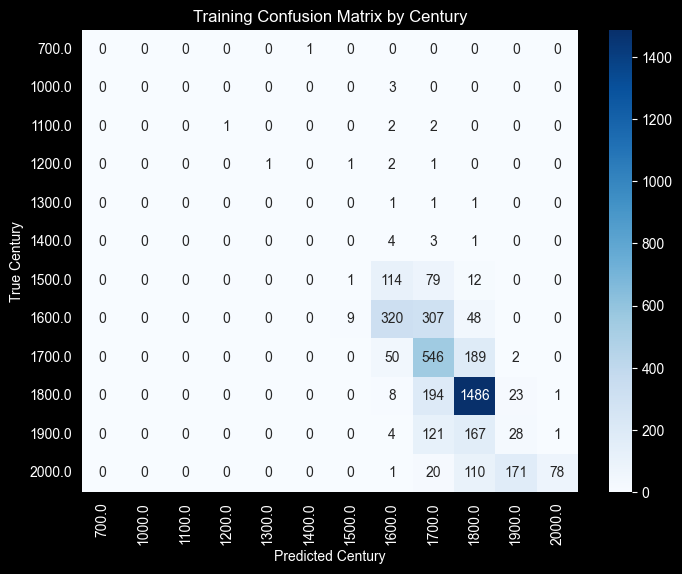

Test per-decade accuracy: 0.093 (9.3%)
Test per-half-century accuracy: 0.311 (31.1%)
Test per-century accuracy: 0.584 (58.4%)

Test sample predictions (10 random rows):


,true_year,predicted_year,true_decade,predicted_decade,true_halfcentury,predicted_halfcentury,true_century,predicted_century
694,1612.0,1614.581849,1610.0,1610.0,1600.0,1600.0,1600.0,1600.0
338,1360.0,1771.989271,1360.0,1770.0,1350.0,1750.0,1300.0,1700.0
123,1884.0,1861.992155,1880.0,1860.0,1850.0,1850.0,1800.0,1800.0
537,1844.0,1857.131062,1840.0,1850.0,1800.0,1850.0,1800.0,1800.0
523,1838.0,1766.165272,1830.0,1760.0,1800.0,1750.0,1800.0,1700.0
351,1840.0,1847.185018,1840.0,1840.0,1800.0,1800.0,1800.0,1800.0
492,1866.0,1875.762121,1860.0,1870.0,1850.0,1850.0,1800.0,1800.0
215,1856.0,1849.805510,1850.0,1840.0,1850.0,1800.0,1800.0,1800.0
424,1885.0,1833.873786,1880.0,1830.0,1850.0,1800.0,1800.0,1800.0
441,1801.0,1840.816047,1800.0,1840.0,1800.0,1800.0,1800.0,1800.0


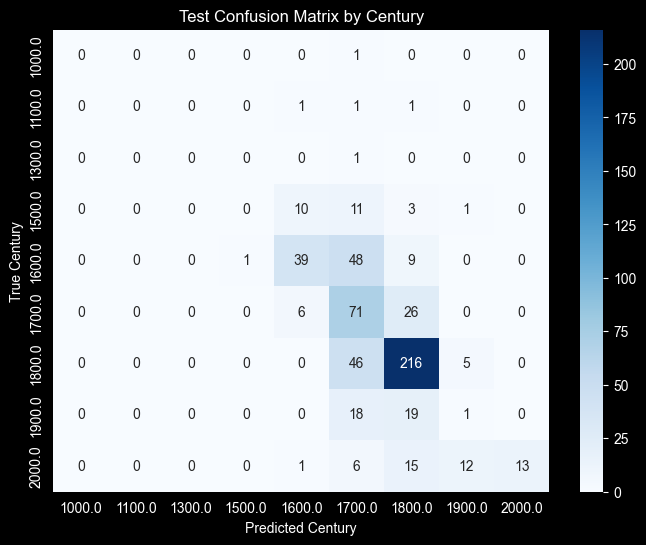

In [65]:
def multi_scale_accuracy_analysis(X_split, y_split, preds, split_name="Split"):
    # Decade accuracy
    y_decade = (y_split // 10) * 10
    preds_decade = (preds // 10) * 10
    accuracy_decade = np.mean(y_decade == preds_decade)
    print(f"{split_name} per-decade accuracy: {accuracy_decade:.3f} ({accuracy_decade*100:.1f}%)")

    # Half-century accuracy (50-year bins)
    y_halfcentury = (y_split // 50) * 50
    preds_halfcentury = (preds // 50) * 50
    accuracy_halfcentury = np.mean(y_halfcentury == preds_halfcentury)
    print(f"{split_name} per-half-century accuracy: {accuracy_halfcentury:.3f} ({accuracy_halfcentury*100:.1f}%)")

    # Century accuracy
    y_century = (y_split // 100) * 100
    preds_century = (preds // 100) * 100
    accuracy_century = np.mean(y_century == preds_century)
    print(f"{split_name} per-century accuracy: {accuracy_century:.3f} ({accuracy_century*100:.1f}%)")

    # Sample predictions
    sample_df = X_split.copy()
    sample_df["true_year"] = y_split.values
    sample_df["predicted_year"] = preds
    sample_df["true_decade"] = y_decade.values
    sample_df["predicted_decade"] = preds_decade
    sample_df["true_halfcentury"] = y_halfcentury.values
    sample_df["predicted_halfcentury"] = preds_halfcentury
    sample_df["true_century"] = y_century.values
    sample_df["predicted_century"] = preds_century
    print(f"\n{split_name} sample predictions (10 random rows):")
    display(sample_df.sample(10, random_state=42)[
        ["true_year","predicted_year","true_decade","predicted_decade",
         "true_halfcentury","predicted_halfcentury","true_century","predicted_century"]
    ])

    # Confusion matrix by century
    cm = confusion_matrix(y_century, preds_century, labels=np.unique(y_century))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=np.unique(y_century),
                yticklabels=np.unique(y_century),
                cmap="Blues")
    plt.xlabel("Predicted Century")
    plt.ylabel("True Century")
    plt.title(f"{split_name} Confusion Matrix by Century")
    plt.show()


preds_train = model.predict(X_train)
multi_scale_accuracy_analysis(X_train, y_train, preds_train, split_name="Training")
multi_scale_accuracy_analysis(X_test_final, y_test_final, preds_test, split_name="Test")


### 8. Time-bucket accuracy (decades, half-centuries, centuries)

Exact-year prediction is hard and sometimes unnecessary. Here we look at **coarser time buckets**:
- decade-level (e.g. 1840s vs 1850s)
- half-century (50-year windows)
- century (100-year windows)

We compute accuracy at each granularities and visualize a confusion matrix per century.

In [66]:
def tolerance_accuracy_analysis(X_split, y_split, preds, split_name="Split"):
    # ±5 years (decade window)
    accuracy_decade = np.mean(np.abs(preds - y_split.values) <= 5)
    print(f"{split_name} ±5-year accuracy (decade window): {accuracy_decade:.3f} ({accuracy_decade*100:.1f}%)")

    # ±25 years (half-century)
    accuracy_halfcentury = np.mean(np.abs(preds - y_split.values) <= 25)
    print(f"{split_name} ±25-year accuracy (half-century window): {accuracy_halfcentury:.3f} ({accuracy_halfcentury*100:.1f}%)")

    # ±50 years (century)
    accuracy_century = np.mean(np.abs(preds - y_split.values) <= 50)
    print(f"{split_name} ±50-year accuracy (century window): {accuracy_century:.3f} ({accuracy_century*100:.1f}%)")

preds_train = model.predict(X_train)
tolerance_accuracy_analysis(X_train, y_train, preds_train, split_name="Training")
tolerance_accuracy_analysis(X_test_final, y_test_final, preds_test, split_name="Test")


Training ±5-year accuracy (decade window): 0.120 (12.0%)
Training ±25-year accuracy (half-century window): 0.375 (37.5%)
Training ±50-year accuracy (century window): 0.611 (61.1%)
Test ±5-year accuracy (decade window): 0.103 (10.3%)
Test ±25-year accuracy (half-century window): 0.349 (34.9%)
Test ±50-year accuracy (century window): 0.596 (59.6%)


### 9. Accuracy with tolerance windows

Finally, we ask a slightly different question: *how often is the model "close enough"?*

We therefore compute the fraction of predictions that fall within:
- **±5 years** (roughly decade-level)
- **±25 years** (half-century)
- **±50 years** (century)

These metrics complement MAE/RMSE and give a more interpretable sense of how the model behaves over time.